# Setup

In [210]:
import os
import subprocess

# CRITICAL: Set graphviz path BEFORE importing anything else
graphviz_path = '/opt/homebrew/opt/graphviz/bin'
dot_path = os.path.join(graphviz_path, 'dot')

os.environ['PATH'] = graphviz_path + ':' + os.environ.get('PATH', '')
os.environ['GRAPHVIZ_DOT'] = dot_path

# Verify graphviz is available
try:
    result = subprocess.run([dot_path, '-V'], capture_output=True, text=True, timeout=5)
    print(f"✓ Graphviz ready: {result.stderr.strip()}")
except Exception as e:
    print(f"⚠ Warning: Graphviz check failed: {e}")

# Now import everything else
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow_decision_forests as tfdf

import numpy as np
import pandas as pd
import tensorflow as tf
import tf_keras
import math
import matplotlib.pyplot as plt

✓ Graphviz ready: dot - graphviz version 14.1.3 (20260303.0454)


In [211]:
df_Train = pd.read_csv('/Users/game./Documents/Google Data Sci/house-prices-advanced-regression-techniques/train.csv')

# EDA

In [212]:
df_Train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [213]:
# See which columns have missing values and how many
missing_summary = df_Train.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
print(missing_summary)

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


# Preprocess

In [214]:
df_Train = df_Train.drop(columns=['Id', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'])
df_Train = df_Train.dropna()

In [215]:
def get_feature(df, feature_name):
    y = df['SalePrice']
    X = df.drop(columns=['SalePrice'])
    X['MSSubClass'] = X['MSSubClass'].astype(str)
    X['MoSold'] = X['MoSold'].astype(str)
    X['YrSold'] = X['YrSold'].astype(str)
    numerical_features = X.select_dtypes(include=['int64', 'float64'])
    categorical_features = X.select_dtypes(include=['object', 'category'])
    return numerical_features, categorical_features, y

In [216]:
X_num, X_cat, y = get_feature(df_Train, 'SalePrice')

/var/folders/2m/xyjw95m92xscbmz53j7wmxq00000gp/T/ipykernel_42106/913533302.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category'])


In [217]:
len(y)

1094

# Model

In [218]:
# Prepare training and test datasets
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Convert to TensorFlow datasets
BATCH_SIZE = 32

# Create training dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train.values.astype(np.float32), y_train.values.astype(np.float32)))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

# Create test dataset
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.values.astype(np.float32), y_test.values.astype(np.float32)))
test_dataset = test_dataset.batch(BATCH_SIZE)

print(f"✓ Datasets prepared with batch size: {BATCH_SIZE}")

Training set size: 875
Test set size: 219
✓ Datasets prepared with batch size: 32


In [219]:
# Input features.
num_features = X_train.shape[1]
raw_features = tf_keras.layers.Input(shape=(num_features,))

# Stage 1
# =======

# Common learnable pre-processing
preprocessor = tf_keras.layers.Dense(10, activation="linear")
preprocess_features = preprocessor(raw_features)

# Stage 2
# =======



# Model #1: NN
m1_z1 = tf_keras.layers.Dense(5, activation="linear")(preprocess_features)
m1_pred = tf_keras.layers.Dense(1)(m1_z1)  # NO activation for regression!

# Model #2: NN
m2_z1 = tf_keras.layers.Dense(5, activation="linear")(preprocess_features)
m2_pred = tf_keras.layers.Dense(1)(m2_z1)  # NO activation for regression!


# Model #3: DF
model_3 = tfdf.keras.RandomForestModel(num_trees=1000, random_seed=1234)
m3_pred = model_3(preprocess_features)

# Model #4: DF
model_4 = tfdf.keras.RandomForestModel(
    num_trees=1000,
    #split_axis="SPARSE_OBLIQUE", # Uncomment this line to increase the quality of this model
    random_seed=4567)
m4_pred = model_4(preprocess_features)

# Model #5: Additional NN with ReLU activation
m5_z1 = tf_keras.layers.Dense(10, activation="relu")(preprocess_features)
m5_z2 = tf_keras.layers.Dense(5, activation="relu")(m5_z1)
m5_pred = tf_keras.layers.Dense(1)(m5_z2)  # NO activation for regression

# Since TF-DF uses deterministic learning algorithms, you should set the model's
# training seed to different values otherwise both
# `tfdf.keras.RandomForestModel` will be exactly the same.

# Stage 3: Ensemble Averaging
# ============================
# Ensemble with 3 NN models
mean_nn_only = tf.reduce_mean(tf.stack([m1_pred, m2_pred, m5_pred], axis=0), axis=0)

# Full ensemble with all 5 models (3 NNs + 2 Tree models trained separately)
mean_nn_and_df = tf.reduce_mean(
    tf.stack([m1_pred, m2_pred, m5_pred, m3_pred, m4_pred], axis=0), axis=0)

# Keras Models
# ============

ensemble_nn_only = tf_keras.models.Model(raw_features, mean_nn_only)
ensemble_nn_and_df = tf_keras.models.Model(raw_features, mean_nn_and_df)

Use /var/folders/2m/xyjw95m92xscbmz53j7wmxq00000gp/T/tmp79w9kpc4 as temporary training directory


Use /var/folders/2m/xyjw95m92xscbmz53j7wmxq00000gp/T/tmpsv2ce28w as temporary training directory


In [ ]:
%%time

# Train NN Ensemble
print("="*60)
print("Training Full Ensemble (3 NNs + 2 Random Forests)")
print("="*60)

# 1. Compile for Regression
ensemble_nn_and_df.compile(
    optimizer=tf_keras.optimizers.legacy.Adam(),  # Use legacy for Mac M1
    loss=tf_keras.losses.MeanSquaredError(),
    metrics=[tf_keras.metrics.MeanAbsoluteError()]
)

# 2. Fit the model - Train the NN portion (m1, m2, m5)
print("\nTraining ensemble_nn_and_df (NN portion: m1, m2, m5)...")
ensemble_nn_and_df.fit(
    train_dataset, 
    epochs=50,  # Reduced from 100 for faster training
    validation_data=test_dataset,
    verbose=1
)

print("\n" + "="*60)
print("Training Random Forest Models (Direct - NOT in ensemble)")
print("="*60)

# Train Tree Models SEPARATELY (not inside ensemble)
# NOTE: TF-DF RandomForest models need to be trained outside the functional API
preprocessor_model = tf_keras.models.Model(inputs=raw_features, outputs=preprocess_features)
print("\nExtracting preprocessed features...")
X_train_preprocessed = preprocessor_model.predict(X_train, verbose=0)
print(f"Preprocessed features shape: {X_train_preprocessed.shape}")

# Train model_3 for regression
print("\nTraining model_3 (Random Forest)...")
model_3.fit(x=X_train_preprocessed, y=y_train, verbose=1)

# Train model_4 for regression  
print("\nTraining model_4 (Random Forest)...")
model_4.fit(x=X_train_preprocessed, y=y_train, verbose=1)

print("\n" + "="*60)
print("✓ All models trained successfully!")
print("="*60)

Training Neural Network Ensemble (3 models)

Training ensemble_nn_only...
Epoch 1/50
Epoch 1/50
28/28 [==============================] - 0s 3ms/step - loss: 41417703424.0000 - mean_absolute_error: 186259.9062 - val_loss: 42127847424.0000 - val_mean_absolute_error: 186146.6250
Epoch 2/50
28/28 [==============================] - 0s 3ms/step - loss: 41417703424.0000 - mean_absolute_error: 186259.9062 - val_loss: 42127847424.0000 - val_mean_absolute_error: 186146.6250
Epoch 2/50
28/28 [==============================] - 0s 1ms/step - loss: 40448741376.0000 - mean_absolute_error: 183848.0625 - val_loss: 41225961472.0000 - val_mean_absolute_error: 183849.1094
Epoch 3/50
28/28 [==============================] - 0s 1ms/step - loss: 40448741376.0000 - mean_absolute_error: 183848.0625 - val_loss: 41225961472.0000 - val_mean_absolute_error: 183849.1094
Epoch 3/50
28/28 [==============================] - 0s 1ms/step - loss: 39273525248.0000 - mean_absolute_error: 180898.8750 - val_loss: 39938408448

I0000 00:00:1773682400.175384  349268 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1773682400.175528  349268 kernel.cc:783] Collect training examples
I0000 00:00:1773682400.175542  349268 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1773682400.177201  349268 kernel.cc:401] Number of batches: 28
I0000 00:00:1773682400.177208  349268 kernel.cc:402] Number of examples: 875
I0000 00:00:1773682400.177525  349268 kernel.cc:802] Training dataset:
Number of records: 875
Number of columns: 11

Number of columns by type:
	NUMERICAL: 10 (90.9091%)
	CATEGORICAL: 1 (9.09091%)

Columns:

NUMERICAL: 10 (90.9091%)
	1: "data:0.0" NUMERICAL me

CPU times: user 4min 39s, sys: 6.5 s, total: 4min 45s
Wall time: 39.3 s


2026-03-17 00:33:57.468454: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at kernel_long_process.cc:157 : INVALID_ARGUMENT: The label column has 745002 classes, which is above the limit of 46340 classes


InvalidArgumentError: {{function_node __wrapped__SimpleMLCheckStatus_device_/job:localhost/replica:0/task:0/device:CPU:0}} The label column has 745002 classes, which is above the limit of 46340 classes [Op:SimpleMLCheckStatus] name: 

In [ ]:
# Train Tree
preprocessor_model = tf_keras.models.Model(inputs=raw_features, outputs=preprocess_features)
X_train_preprocessed = preprocessor_model.predict(X_train)
model_3.fit(x=X_train_preprocessed, y=y_train)
model_4.fit(x=X_train_preprocessed, y=y_train)

# Eval

In [ ]:
# Evaluation on Test Set
print("\n" + "=" * 60)
print("MODEL EVALUATION ON TEST SET")
print("=" * 60)

# Evaluate the model on test dataset
test_loss, test_mae = ensemble_nn_and_df.evaluate(test_dataset, verbose=0)

print(f"\nTest Results:")
print(f"  Loss (MSE): ${test_loss:,.2f}")
print(f"  MAE: ${test_mae:,.2f}")

# Make predictions on test set
y_pred_test = ensemble_nn_and_df.predict(test_dataset, verbose=0)

# Calculate additional metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Flatten predictions
y_pred_test_flat = y_pred_test.flatten()

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_test_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test_flat)
r2 = r2_score(y_test, y_pred_test_flat)

print(f"\nDetailed Metrics:")
print(f"  RMSE: ${rmse:,.2f}")
print(f"  MAE: ${mae:,.2f}")
print(f"  R² Score: {r2:.4f}")
print(f"  Mean Price (Test): ${y_test.mean():,.2f}")

# Show sample predictions
print(f"\nSample Predictions vs Actual:")
print("-" * 60)
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_test_flat[:10],
    'Error': np.abs(y_test.values[:10] - y_pred_test_flat[:10])
})
print(comparison.to_string(index=False))
print("\n" + "=" * 60)


MODEL EVALUATION ON TEST SET

Test Results:
  Loss (MSE): $2,581,683,968.00
  MAE: $36,510.11

Test Results:
  Loss (MSE): $2,581,683,968.00
  MAE: $36,510.11

Detailed Metrics:
  RMSE: $50,810.27
  MAE: $36,510.11
  R² Score: 0.6568
  Mean Price (Test): $187,835.28

Sample Predictions vs Actual:
------------------------------------------------------------
 Actual     Predicted        Error
 144000 167155.718750 23155.718750
 127000 133120.531250  6120.531250
 155000 162005.515625  7005.515625
 119000 137342.625000 18342.625000
 140000 136761.625000  3238.375000
 193000 202938.328125  9938.328125
  76000 121852.312500 45852.312500
 253293 281166.156250 27873.156250
 185000 169217.859375 15782.140625
 239799 228744.671875 11054.328125


Detailed Metrics:
  RMSE: $50,810.27
  MAE: $36,510.11
  R² Score: 0.6568
  Mean Price (Test): $187,835.28

Sample Predictions vs Actual:
------------------------------------------------------------
 Actual     Predicted        Error
 144000 167155.7187

In [ ]:
y_pred_test = y_pred_test.reshape(-1)

(array([[ 7., 15., 30., 41., 27., 25., 12., 19.,  9., 10.,  5.,  6.,  5.,
          2.,  2.,  1.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  1.],
        [ 0.,  3.,  9., 38., 51., 32., 39., 24., 11.,  7.,  2.,  1.,  1.,
          0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.]]),
 array([ 60000.        ,  83166.66666667, 106333.33333333, 129500.        ,
        152666.66666667, 175833.33333333, 199000.        , 222166.66666667,
        245333.33333333, 268500.        , 291666.66666667, 314833.33333333,
        338000.        , 361166.66666667, 384333.33333333, 407500.        ,
        430666.66666667, 453833.33333333, 477000.        , 500166.66666667,
        523333.33333333, 546500.        , 569666.66666667, 592833.33333333,
        616000.        , 639166.66666667, 662333.33333333, 685500.        ,
        708666.66666667, 731833.33333333, 755000.        ]),
 <a list of 2 BarContainer objects>)

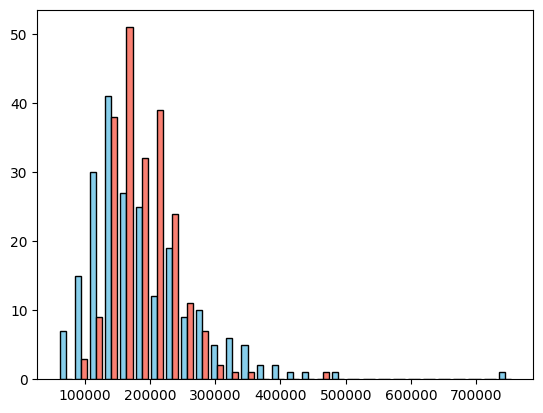

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist([y_test, y_pred_test], bins=30, color=['skyblue', 'salmon'], edgecolor='black', label=['Actual', 'Predicted'])

# Submission

In [ ]:
# Load test data and prepare for submission
print("=" * 70)
print("KAGGLE SUBMISSION PREPARATION")
print("=" * 70)

# 1. Load test data
test_df = pd.read_csv('/Users/game./Documents/Google Data Sci/house-prices-advanced-regression-techniques/test.csv')
print(f"\n✓ Test data loaded: {test_df.shape[0]} samples, {test_df.shape[1]} columns")

# 2. Load sample submission
sample_submission = pd.read_csv('/Users/game./Documents/Google Data Sci/house-prices-advanced-regression-techniques/sample_submission.csv')
print(f"✓ Sample submission loaded: {sample_submission.shape[0]} rows")
print(f"  Columns: {sample_submission.columns.tolist()}")

# 3. Apply same preprocessing to test data
test_df_processed = test_df.drop(columns=['Id', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], errors='ignore')

# Get numerical features only (same as training)
test_features = test_df_processed[X_num.columns].copy()

# Handle missing values in test set (fill with mean from training)
for col in test_features.columns:
    if test_features[col].isnull().any():
        test_features[col] = test_features[col].fillna(X_num[col].mean())

print(f"\n✓ Test features prepared: {test_features.shape}")

# 4. Create TensorFlow dataset for predictions
test_submission_dataset = tf.data.Dataset.from_tensor_slices(test_features.values.astype(np.float32))
test_submission_dataset = test_submission_dataset.batch(BATCH_SIZE)

# 5. Make predictions
print(f"\nMaking predictions on test set...")
y_pred_submission = ensemble_nn_and_df.predict(test_submission_dataset, verbose=0)
y_pred_submission = y_pred_submission.flatten()

# Handle any remaining NaN values
y_pred_submission = np.nan_to_num(y_pred_submission, nan=y_train.mean())

print(f"✓ Predictions made: {len(y_pred_submission)} predictions")
print(f"  Min: ${y_pred_submission.min():,.2f}")
print(f"  Max: ${y_pred_submission.max():,.2f}")
print(f"  Mean: ${y_pred_submission.mean():,.2f}")
print(f"  NaN count: {np.isnan(y_pred_submission).sum()}")

# 6. Create submission dataframe
submission = sample_submission.copy()
submission['SalePrice'] = y_pred_submission

print(f"\n✓ Submission dataframe created:")
print(submission.head(10))

# 7. Save submission
submission_path = '/Users/game./Documents/Google Data Sci/submission.csv'
submission.to_csv(submission_path, index=False)
print(f"\n✓ Submission saved to: {submission_path}")
print(f"  Total predictions: {len(submission)}")
print(f"  File size: {os.path.getsize(submission_path) / 1024:.2f} KB")
print("\n" + "=" * 70)

KAGGLE SUBMISSION PREPARATION

✓ Test data loaded: 1459 samples, 80 columns
✓ Sample submission loaded: 1459 rows
  Columns: ['Id', 'SalePrice']

✓ Test data loaded: 1459 samples, 80 columns
✓ Sample submission loaded: 1459 rows
  Columns: ['Id', 'SalePrice']

✓ Test features prepared: (1459, 33)

Making predictions on test set...

✓ Test features prepared: (1459, 33)

Making predictions on test set...
✓ Predictions made: 1459 predictions
  Min: $74,912.84
  Max: $520,828.53
  Mean: $183,660.50
  NaN count: 0

✓ Submission dataframe created:
     Id      SalePrice
0  1461  154448.859375
1  1462  111807.570312
2  1463  196088.140625
3  1464  197460.875000
4  1465  176864.046875
5  1466  184318.796875
6  1467  180771.390625
7  1468  166262.171875
8  1469  187036.140625
9  1470  149871.437500

✓ Submission saved to: /Users/game./Documents/Google Data Sci/submission.csv
  Total predictions: 1459
  File size: 21.19 KB

✓ Predictions made: 1459 predictions
  Min: $74,912.84
  Max: $520,828.5